# Library & Data import

In [28]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
import pydeck as pdk

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shapely import wkt

In [29]:
df = pd.read_csv('..\Data\\Org_W_Duplicates_data_1_0.csv', low_memory=False)
main_df = pd.read_csv('..\Data\\311_2025_Jan_Dec.csv', low_memory=False) # The dataframe before the changes we applied in FinalTable notebook

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Idan\AppData\Local\Temp\ipykernel_39116\466393794.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('..\Data\\Org_W_Duplicates_data_1_0.csv', low_memory=False)
C:\Users\Idan\AppData\Local\Temp\ipykernel_39116\466393794.py:2: SyntaxWarning: invalid escape sequence '\D'
  main_df = pd.read_csv('..\Data\\311_2025_Jan_Dec.csv', low_memory=False) # The dataframe before the changes we applied in FinalTable notebook


In [30]:
pd.set_option('display.max_rows', 200)  # In case rows are being cut off 

# First look at the data

In [31]:
# Dataset shape
print("There are {} rows and {} columns in the dataset".format(df.shape[0], df.shape[1]))

There are 3645995 rows and 10 columns in the dataset


In [32]:
# Quick look into the first 5 rows of the dataset
df.head() 

,City,Incident Zip,Agency,Location Type,Closed Date,Created Date,Status,Location,Resolution Time,Complaint_Type
0,WOODSIDE,11377,NYPD,Street/Sidewalk,2025-12-31 02:44:50,2025-12-31 00:30:26,Closed,POINT (-73.907196579197 40.743018746122),2.0,Vehicles & Parking
1,FAR ROCKAWAY,11694,HPD,RESIDENTIAL BUILDING,2026-01-02 17:18:55,2025-12-31 00:30:19,Closed,POINT (-73.839021963252 40.577671995863),64.0,Housing & Building Maintenance
2,NEW YORK,10033,HPD,RESIDENTIAL BUILDING,2026-01-02 10:07:10,2025-12-31 00:30:06,Closed,POINT (-73.937239002314 40.851013911318),57.0,Housing & Building Maintenance
3,BROOKLYN,11207,HPD,RESIDENTIAL BUILDING,2026-01-02 13:49:56,2025-12-31 00:30:05,Closed,POINT (-73.899924654626 40.663886523056),61.0,Housing & Building Maintenance
4,BROOKLYN,11234,DSNY,Street,2025-12-31 07:32:00,2025-12-31 00:30:00,Closed,POINT (-73.912414463066 40.625294042041),7.0,Vehicles & Parking


In [33]:
# See each column and its data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3645995 entries, 0 to 3645994
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   City             str    
 1   Incident Zip     str    
 2   Agency           str    
 3   Location Type    str    
 4   Closed Date      str    
 5   Created Date     str    
 6   Status           str    
 7   Location         str    
 8   Resolution Time  float64
 9   Complaint_Type   str    
dtypes: float64(1), str(9)
memory usage: 278.2 MB


----=====Valid values=====----
city: Cities in new york metropolitan
Incident Zip: zip code of incident location ( Dtype is str but represents a number - will be converted later)
Agency: Service responsible for the complaint
Location Type: ( Street, Sidewalk, Residential building... )
Status: ( Closed, Open, Processing... )
Location: Cordinates of the complaint
Resolution Time: Time it took to resolve the issue
Complaint Type: ("Housing & Building Maintenance", "Vehicles & Parking"... )

In [34]:
# Lets see the problems people complain about
print(df["Complaint_Type"].unique())

<StringArray>
[            'Vehicles & Parking', 'Housing & Building Maintenance',
                          'Noise',             'Sanitation & Trash',
        'Street & Infrastructure',          'Public Order & Police',
  'Health & Environmental Safety',                     'Other/Misc',
                  'Trees & Parks',             'Construction & DOB',
       'Taxi & For-Hire Vehicles',                 'Animals & Pets']
Length: 12, dtype: str


In [35]:
df["Complaint_Type"].value_counts()

Complaint_Type
Vehicles & Parking                877554
Noise                             831176
Housing & Building Maintenance    786282
Street & Infrastructure           229255
Sanitation & Trash                224815
Public Order & Police             179686
Other/Misc                        177515
Health & Environmental Safety     141139
Trees & Parks                      71259
Construction & DOB                 63241
Animals & Pets                     34471
Taxi & For-Hire Vehicles           29602
Name: count, dtype: int64

# Duplicates 

During data remodeling, we have found out that there is a column called "Additional Details" that causes us to have duplicates. The problem with the column is that for the same complaint, we got more rows, but why?  because each row had a different additional detail. In our clustering problem we want to focus on just the complaint type without more details so we decided to remove any duplicates that appear in our data.

In [36]:
# Amount of duplicates
print(df.duplicated().sum())

203147


In [37]:
# The duplicate rows
df[df.duplicated(keep=False)]


,City,Incident Zip,Agency,Location Type,Closed Date,Created Date,Status,Location,Resolution Time,Complaint_Type
51,NEW YORK,10075,HPD,RESIDENTIAL BUILDING,2026-02-28 06:07:17,2025-12-31 00:23:35,Closed,POINT (-73.957188128108 40.772507525524),1421.0,Housing & Building Maintenance
52,NEW YORK,10075,HPD,RESIDENTIAL BUILDING,2026-02-28 06:07:17,2025-12-31 00:23:35,Closed,POINT (-73.957188128108 40.772507525524),1421.0,Housing & Building Maintenance
53,NEW YORK,10075,HPD,RESIDENTIAL BUILDING,2026-02-28 06:07:17,2025-12-31 00:23:35,Closed,POINT (-73.957188128108 40.772507525524),1421.0,Housing & Building Maintenance
169,BROOKLYN,11226,HPD,RESIDENTIAL BUILDING,2026-01-17 16:13:52,2025-12-31 00:03:42,Closed,POINT (-73.95992971344 40.644328077072),424.0,Housing & Building Maintenance
170,BROOKLYN,11226,HPD,RESIDENTIAL BUILDING,2026-01-17 16:13:52,2025-12-31 00:03:42,Closed,POINT (-73.95992971344 40.644328077072),424.0,Housing & Building Maintenance
...,...,...,...,...,...,...,...,...,...,...
3644882,REGO PARK,11374,HPD,RESIDENTIAL BUILDING,2025-05-01 07:10:39,2025-01-01 02:25:08,Closed,POINT (-73.859885543389 40.729233399834),2884.0,Housing & Building Maintenance
3644883,REGO PARK,11374,HPD,RESIDENTIAL BUILDING,2025-05-01 07:10:39,2025-01-01 02:25:08,Closed,POINT (-73.859885543389 40.729233399834),2884.0,Housing & Building Maintenance
3645366,BRONX,10453,HPD,RESIDENTIAL BUILDING,2025-01-28 12:04:14,2025-01-01 01:31:26,Closed,POINT (-73.915556577321 40.846743038691),658.0,Housing & Building Maintenance
3645367,BRONX,10453,HPD,RESIDENTIAL BUILDING,2025-01-28 12:04:14,2025-01-01 01:31:26,Closed,POINT (-73.915556577321 40.846743038691),658.0,Housing & Building Maintenance


In [38]:
# Get the index of duplicated rows in df
dup_index = df[df.duplicated()].index
# Use that index to display the full rows from main_df
main_df.loc[dup_index]

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
52,67348640,12/31/2025 12:23:35 AM,02/28/2026 06:07:17 AM,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,MOLD,NaN,RESIDENTIAL BUILDING,10075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.772508,-73.957188,POINT (-73.957188128108 40.772507525524)
53,67350742,12/31/2025 12:23:35 AM,02/28/2026 06:07:17 AM,HPD,Department of Housing Preservation and Develop...,GENERAL,CABINET,DAMAGED OR MISSING,RESIDENTIAL BUILDING,10075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.772508,-73.957188,POINT (-73.957188128108 40.772507525524)
170,67348611,12/31/2025 12:03:42 AM,01/17/2026 04:13:52 PM,HPD,Department of Housing Preservation and Develop...,PLUMBING,RADIATOR,BROKEN OR MISSING,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644328,-73.959930,POINT (-73.95992971344 40.644328077072)
171,67347487,12/31/2025 12:03:42 AM,01/17/2026 04:13:52 PM,HPD,Department of Housing Preservation and Develop...,DOOR/WINDOW,WINDOW FRAME,LOOSE OR DEFECTIVE,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644328,-73.959930,POINT (-73.95992971344 40.644328077072)
172,67348610,12/31/2025 12:03:42 AM,01/17/2026 04:13:52 PM,HPD,Department of Housing Preservation and Develop...,PLUMBING,RADIATOR,AIR VALVE BROKEN OR MISSING,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644328,-73.959930,POINT (-73.95992971344 40.644328077072)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3643610,63595060,01/01/2025 05:33:03 AM,01/03/2025 11:25:03 AM,HPD,Department of Housing Preservation and Develop...,APPLIANCE,ELECTRIC/GAS RANGE,NO GAS OR ELECTRICITY,RESIDENTIAL BUILDING,10027,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.806707,-73.949992,POINT (-73.949992233832 40.806706730552)
3644061,63593914,01/01/2025 04:16:54 AM,01/02/2025 02:14:16 PM,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HEAT,RESIDENTIAL BUILDING,11429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.709782,-73.738919,POINT (-73.73891909692 40.70978181729)
3644883,63595195,01/01/2025 02:25:08 AM,05/01/2025 07:10:39 AM,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,PESTS,MICE,RESIDENTIAL BUILDING,11374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.729233,-73.859886,POINT (-73.859885543389 40.729233399834)
3645367,63595055,01/01/2025 01:31:26 AM,01/28/2025 12:04:14 PM,HPD,Department of Housing Preservation and Develop...,GENERAL,BELL/BUZZER/INTERCOM,BROKEN OR MISSING,RESIDENTIAL BUILDING,10453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.846743,-73.915557,POINT (-73.915556577321 40.846743038691)


Let's focus on a specific duplicate with id 170 and 172

In [39]:
main_df.loc[[170,172]]

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
170,67348611,12/31/2025 12:03:42 AM,01/17/2026 04:13:52 PM,HPD,Department of Housing Preservation and Develop...,PLUMBING,RADIATOR,BROKEN OR MISSING,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644328,-73.95993,POINT (-73.95992971344 40.644328077072)
172,67348610,12/31/2025 12:03:42 AM,01/17/2026 04:13:52 PM,HPD,Department of Housing Preservation and Develop...,PLUMBING,RADIATOR,AIR VALVE BROKEN OR MISSING,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.644328,-73.95993,POINT (-73.95992971344 40.644328077072)


As we can see, the rows are almost identical because its the same complaint: "Plumbing" but why did it create 2 rows? Because of "Additional Details" column! We have got 2 different details for the same problem. As we said in the beginning we will remove all duplicates. ( 363809 rows which is 10% of the data)

In [40]:
# Dropping duplicates
df = df.drop_duplicates(keep=False)
# Validating duplicates removel
print(df.duplicated().sum())

0


In [41]:
# Let's save the table as csv
#df.to_csv("Org_data_2_0.csv", index=False)

# Missing Values

In [42]:
# Number of missing value for each feature.
df.isnull().sum()

City               155630
Incident Zip        29771
Agency                  0
Location Type      427166
Closed Date         69637
Created Date            0
Status                  0
Location            49862
Resolution Time     69637
Complaint_Type          0
dtype: int64

In [43]:
# Percentage of missing values for each feature.
df.isnull().mean()*100

City                4.650629
Incident Zip        0.889635
Agency              0.000000
Location Type      12.764831
Closed Date         2.080935
Created Date        0.000000
Status              0.000000
Location            1.490006
Resolution Time     2.080935
Complaint_Type      0.000000
dtype: float64

This is the data which is Null/None/NaN... But what if the missing data was written as Unknown or Unavailable? Let's check the most common encodings.

In [44]:
# Replace common text based fake nulls with actual NaN val
# List of common fake nulls
fake_nulls = [
    "Unspecified", "UNKNOWN", "Unknown", "unknown", 
    "Not Applicable", "N/A", "NA", "n/a", "na", 
    "None", "none", "TBD", "Other",
    "", " ", "  ", "-", ".",
    "-1", "-999", "99999" 
]

# Apply the replacement across the entire dataframe
# We use regex=False because we are matching exact strings, which is much faster
df.replace(fake_nulls, np.nan, inplace=True)

# Now check the true damage!
print(df.isnull().sum())

City               155630
Incident Zip        29771
Agency                  0
Location Type      432831
Closed Date         69637
Created Date            0
Status                170
Location            49862
Resolution Time     69637
Complaint_Type          0
dtype: int64


We can see that some null values were added to "Location Type". Other than that, no other common fake nulls were found - Great success 

As we can see, most of the columns have missing values. We will decide on how to deal with them later on.

# Outliers

In our data the only numerical column is the "Resoultion Time" column. We will use the describe method on it.

In [45]:
df["Resolution Time"].describe()

count    3.276792e+06
mean     1.749807e+02
std      7.036787e+02
min     -4.800000e+03
25%      0.000000e+00
50%      4.000000e+00
75%      4.500000e+01
max      1.178100e+04
Name: Resolution Time, dtype: float64

According to the describe of the column above, we have some outliers. Let's print the rows and see whats the problem.

In [46]:
df[df["Resolution Time"] < 0]

,City,Incident Zip,Agency,Location Type,Closed Date,Created Date,Status,Location,Resolution Time,Complaint_Type
41501,MANHATTAN,10031,DOT,NaN,2025-12-23 11:45:00,2025-12-26 11:46:00,Pending,POINT (-73.950058143544 40.829592228909),-73.0,Street & Infrastructure
73276,BRONX,10457,DOT,NaN,2025-12-19 11:22:00,2025-12-22 11:22:00,Pending,POINT (-73.901565050601 40.849284525144),-72.0,Street & Infrastructure
73410,QUEENS,11427,DOT,NaN,2025-12-18 11:11:00,2025-12-22 11:12:00,Pending,POINT (-73.766187656624 40.726328264107),-97.0,Street & Infrastructure
105978,MANHATTAN,10023,DOT,NaN,2025-12-17 07:00:00,2025-12-18 18:19:00,Pending,POINT (-73.984975721616 40.779123826816),-36.0,Street & Infrastructure
110090,NaN,NaN,DOT,NaN,2025-12-17 10:33:00,2025-12-18 10:36:00,Pending,NaN,-25.0,Street & Infrastructure
...,...,...,...,...,...,...,...,...,...,...
3536769,BRONX,10465,DOT,NaN,2025-01-03 11:07:00,2025-01-09 11:07:00,Pending,POINT (-73.831174467369 40.831098852313),-144.0,Street & Infrastructure
3536800,BRONX,10461,DOT,NaN,2025-01-03 11:06:00,2025-01-09 11:06:00,Pending,POINT (-73.852895783896 40.852262886222),-144.0,Street & Infrastructure
3536820,BRONX,10471,DOT,NaN,2025-01-03 11:05:00,2025-01-09 11:05:00,Pending,POINT (-73.914780113413 40.89703076378),-144.0,Street & Infrastructure
3582297,MANHATTAN,10280,DOT,NaN,2025-01-04 02:00:00,2025-01-06 07:51:00,Pending,POINT (-74.016765136009 40.709332833023),-54.0,Street & Infrastructure


As we expected the problem was with the creation date and the closing date, one possible explaination for it is a human input error... To fix this issue we will assume the dates were swapped so the best way to is to just multiply the negative resolution time by -1 and swap the dates.

In [47]:
# Identify rows where Resolution Time is negative (dates were swapped)
mask = df["Resolution Time"] < 0

# Swap Created Date and Closed Date for those rows
df.loc[mask, ["Created Date", "Closed Date"]] = (
    df.loc[mask, ["Closed Date", "Created Date"]].values
)

# Flip the negative Resolution Time to positive
df.loc[mask, "Resolution Time"] *= -1


In [48]:
df["Resolution Time"].describe()

count    3.276792e+06
mean     1.750615e+02
std      7.036586e+02
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+00
75%      4.500000e+01
max      1.178100e+04
Name: Resolution Time, dtype: float64

In [49]:
# Let's save the table as csv
df.to_csv("Org_data_2_0.csv", index=False)

# Visualization

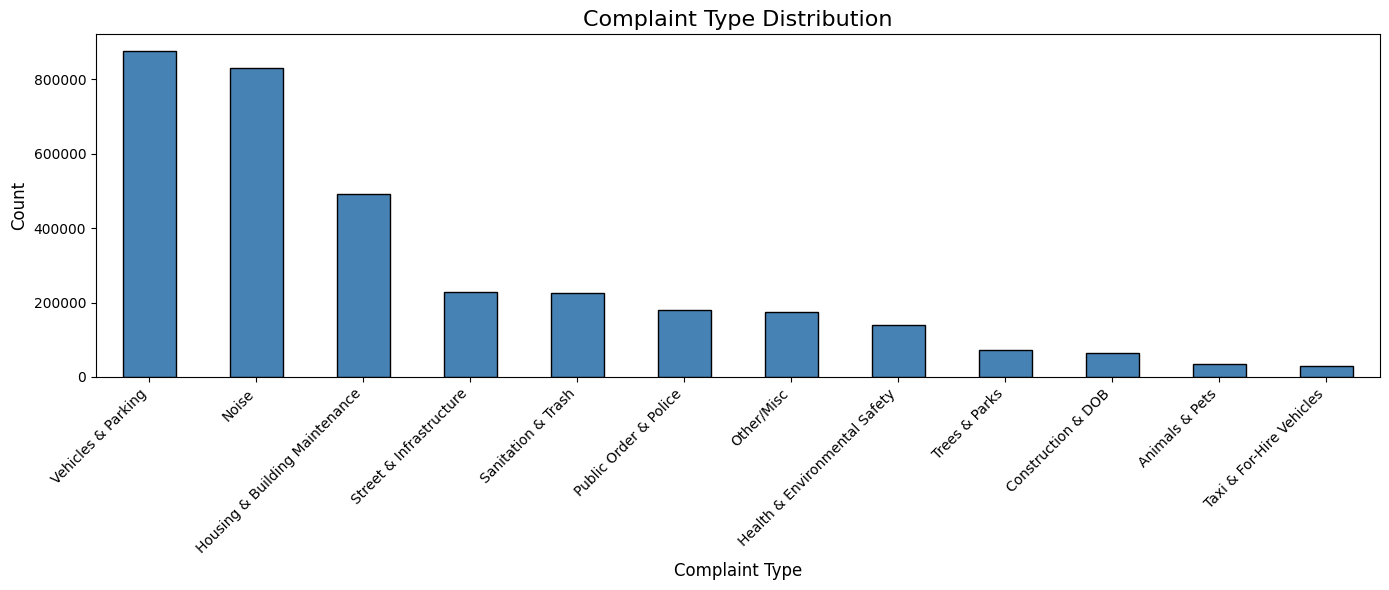

In [50]:
complaint_counts = df["Complaint_Type"].value_counts()

plt.figure(figsize=(14, 6))
complaint_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Complaint Type Distribution", fontsize=16)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


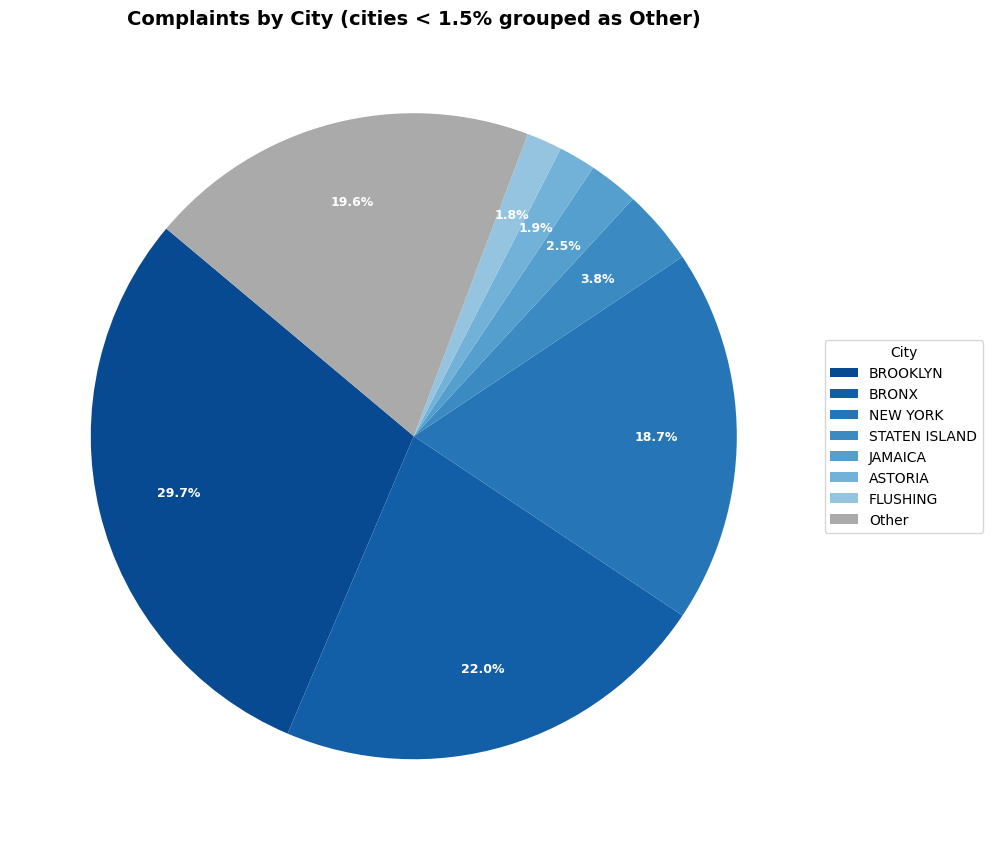

In [51]:
city_counts = df["City"].value_counts()
# Split into >= 1.5% and "Other"
threshold = 0.015 * city_counts.sum()
main = city_counts[city_counts >= threshold]
other_sum = city_counts[city_counts < threshold].sum()
if other_sum > 0:
    main["Other"] = other_sum
# Blue palette for main slices, grey for "Other"
blues = plt.cm.Blues(np.linspace(0.9, 0.4, len(main) - 1))
colors = list(blues) + ["#aaaaaa"]  # grey for "Other"
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    main.values,
    labels=None,                # no labels on the chart to avoid text collision (use legend instead)
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    colors=colors
)
# Style percentage text
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")
    autotext.set_fontweight("bold")
# Legend to avoid text collision
ax.legend(
    wedges,
    main.index,
    title="City",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)
ax.set_title("Complaints by City (cities < 1.5% grouped as Other)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

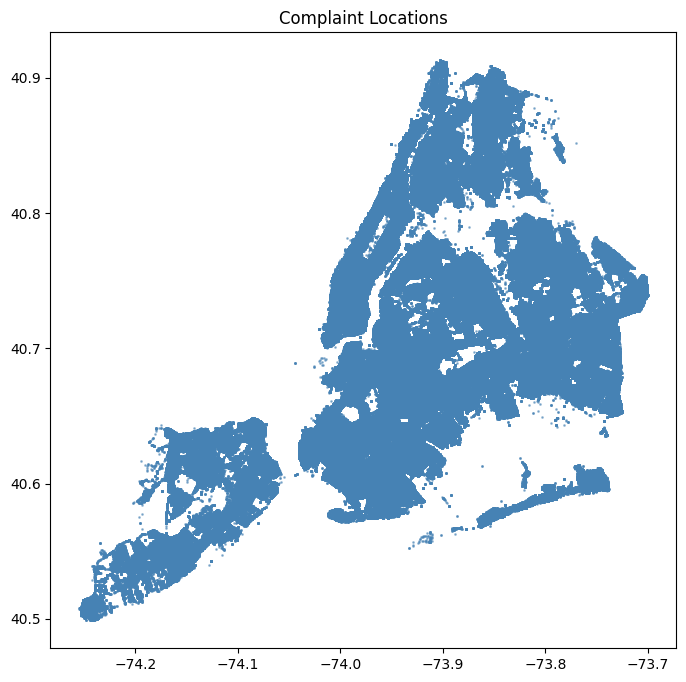

In [52]:
# Step 1: Drop rows with no location
geo_df = df.dropna(subset=["Location"], inplace = False).copy()

# Step 2: Parse "POINT (x y)" string into shapely geometry we use shapely to work with Points like this. 
geo_df["geometry"] = gpd.GeoSeries.from_wkt(geo_df["Location"])

# Step 3: Create GeoDataFrame (CRS 4326 = standard lat/lon)
geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry", crs="EPSG:4326")

# Step 4: Plot
geo_df.plot(figsize=(10, 8), markersize=1, color="steelblue", alpha=0.5)
plt.title("Complaint Locations")
plt.show()

In [53]:
df_clean = df.dropna(subset=["Location"])

gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.GeoSeries.from_wkt(df_clean["Location"]),
    crs="EPSG:4326"
)

gdf["lat"] = gdf.geometry.y
gdf["lon"] = gdf.geometry.x

# Sample 50k random points
gdf_sample = gdf.sample(n=min(10_000, len(gdf)), random_state=42)
print(f"Plotting {len(gdf_sample)} points")

m = folium.Map(location=[gdf_sample["lat"].mean(), gdf_sample["lon"].mean()], zoom_start=10)

for _, row in gdf_sample.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

display(m)


Plotting 10000 points


In [54]:
from folium.plugins import HeatMap

# Sample 50k random points (set random_state for reproducibility)
sample_size = min(10_000, len(gdf))  # won't crash if data < 50k
gdf_sample = gdf.sample(n=sample_size, random_state=42)

print(f"Plotting {len(gdf_sample)} sampled points")

m = folium.Map(
    location=[gdf_sample["lat"].mean(), gdf_sample["lon"].mean()],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

HeatMap(data=list(zip(gdf_sample["lat"], gdf_sample["lon"])), radius=10, blur=8).add_to(m)

display(m)


Plotting 10000 sampled points
